<a href="https://colab.research.google.com/github/jamesaustin2564/IS-4487-F26/blob/main/Assignments/assignment_04_data_understanding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IS4487 Week 4 - Assignment

### Outline

Our Goals with this Project:

1. Import and review the data
2. Perform EDA and Clean Data

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_04_data_understanding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Business Case: AdviseInvest
You work on a small team of data analysts at AdviseInvest, a venture-backed startup. The Director of Sales at AdviseInvest has approached your team asking for help solving a staffing problem.

### The Company
The company's mission is to provide tools and support to help ordinary people gain control of their personal finances. The company leverages technology to provide affordable financial advice to a national client base.

Customers who reach AdviseInvest's website go through five steps:

- Open an account.
- Complete a customer profile form with basic information about their background and finances.
- Schedule a free phone conversation with a sales representative during a 1-hour window of time.
- Attend the free phone conversation.
- Buy a financial plan.
- There are three types of financial plans: Beginner, Intermediate, and Advanced. Each is sold at a different price, and there are varying degrees of personalization. After a customer purchases a financial plan, the customer is assigned a financial planner who helps determine the customer's goals and advises the customer on spending decisions.

### The Problem
Some customers are lost at each stage of the process. Steps 3 and 4 are particularly challenging because approximately 50% of those who schedule a phone conversation fail to pick up the call. This leads to inefficiencies from a staffing perspective.

AdviseInvest has 4 sales reps on staff during each particular 1-hour window. Each of the 4 reps is assigned 2 prospective customers per hour, which means that the company schedules a total of 8 phone calls per hour. The calls are outgoing: sales reps call customers who scheduled a phone conversation during that hour window.

Unfortunately, as noted above, many of the customers who scheduled a call do not answer. As a consequence, sales reps are often left underutilized. Moreover, they are underutilized unevenly. For example, it is possible that one sales rep will not do any sales calls during that hour, whereas another will be busy the entire hour with two calls. Sales reps have nothing to do when customers do not answer the scheduled phone call.

For this assignment, the variable `answered` is your target.  

### AdviseInvest Data Dictionary

| Variable | Description | Type | Code |
|:---|:---|:---|:---|
| customer_id | Unique customer identifier | Numeric | |
| Answered | Customer response | Binary | 0: customer did not answer scheduled call; 1: customer answered scheduled call |
| Income | Customer income in US dollars | Numeric | |
| Female | Customer gender | Binary | 0: female; 1: male |
| Age | Age in years | Numeric | |
| Job | Nature of job | Categorical | 0 : unemployed; 1 : entry level position; 2 : midlevel position; 3 : management/ self-employed/ highly qualified employee/ officer |
| Num_dependents | Number of people for whom the customer provides maintenance | Numeric | |
| Rent | Customer rents | Binary | 0: no; 1: yes |
| Own_res | Customer owns residence | Binary | 0: no; 1: yes |
| New_car | Recent new car purchase | Binary | New car purchase in the last 3 months: 0: no, 1: yes |
| Chk_acct | Checking account status | Categorical | 0 : no checking account; 1: checking < 200 USD; 2 : 200 < checking < 2000 USD; 3: 2000 < checking < 35000 USD; 4: >= 3500 USD |
| Sav_acct | Average balance in savings account | Categorical | 0 : no savings account; 1 : 100 <= savings < 500 USD; 2 : 500 <= savings < 2000 USD; 3 : 2000 < savings < 35000 USD; 4: >= 3500 USD |
| Num_accts | Number of accounts owned by customer | Numeric | |
| Mobile | Mobile phone | Binary | 0: customer provided non‐mobile phone for follow‐up call; 1: customer provided mobile phone for follow‐up call |
| Product | Type of product purchased after conversation with sales rep | Categorical | 0: customer did not answer call; 1: customer answered but did not purchase a product; 2: customer answered and purchased Beginner plan; 3: customer answered and purchased Intermediate plan; 4: customer answered and purchased Advanced plan |


### Load Libraries

Import the libraries you will need, such as:
- Pandas
- Sklearn
- Matplotlib


In [1]:
import pandas as pd
import sklearn
import matplotlib.pyplot as plt

## Step 1: Initial Data Understanding

### Do the following:
 1. Import data from the AdviseInvest historical dataset into a dataframe (in GitHub go to the DataSets folder and look for `adviseinvest_historical_data.csv`)
 2. Show the datatypes
 3. Describe the dataset

 Think about if there are any outliers, missing values, or duplicates.  We will cover those topics more next week.  

In [2]:
url = 'https://raw.githubusercontent.com/Stan-Pugsley/is_4487_base/main/DataSets/adviseinvest_historical_data.csv'
df = pd.read_csv(url)
df.head()

,customer_id,answered,income,female,age,job,num_dependents,rent,own_res,new_car,chk_acct,sav_acct,num_accts,mobile,product
0,10098,0,-65600,0,24,2,1,0,1,1.0,1,1,3,0,0
1,184,0,4330,0,24,2,2,1,0,0.0,1,3,1,0,0
2,194,0,4330,0,22,2,1,1,0,0.0,3,0,0,0,0
3,689,0,4330,0,24,2,2,1,0,0.0,1,3,1,0,0
4,811,0,4330,0,22,2,1,1,0,0.0,3,0,0,0,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29504 entries, 0 to 29503
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   customer_id     29504 non-null  int64  
 1   answered        29504 non-null  int64  
 2   income          29504 non-null  int64  
 3   female          29504 non-null  object 
 4   age             29504 non-null  int64  
 5   job             29504 non-null  int64  
 6   num_dependents  29504 non-null  int64  
 7   rent            29504 non-null  int64  
 8   own_res         29504 non-null  int64  
 9   new_car         29502 non-null  float64
 10  chk_acct        29504 non-null  int64  
 11  sav_acct        29504 non-null  int64  
 12  num_accts       29504 non-null  int64  
 13  mobile          29504 non-null  int64  
 14  product         29504 non-null  int64  
dtypes: float64(1), int64(13), object(1)
memory usage: 3.4+ MB


In [4]:
df.describe()

,customer_id,answered,income,age,job,num_dependents,rent,own_res,new_car,chk_acct,sav_acct,num_accts,mobile,product
count,29504.000000,29504.000000,29504.000000,29504.000000,29504.000000,29504.000000,29504.000000,29504.000000,29502.000000,29504.000000,29504.000000,29504.000000,29504.000000,29504.000000
mean,14850.475563,0.546638,33766.893303,34.773454,1.915401,1.140998,0.210412,0.681128,0.240797,1.468547,0.956616,2.458345,0.091106,1.535792
std,8517.254310,0.497829,29379.202710,11.369865,0.658183,0.348025,0.407608,0.466047,0.427575,1.234727,1.483946,19.497380,0.287765,1.625916
min,99.000000,0.000000,-65600.000000,19.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,7474.750000,0.000000,13550.000000,26.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000
50%,14850.500000,1.000000,23310.000000,32.000000,2.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,2.000000,0.000000,1.000000
75%,22226.250000,1.000000,41690.000000,40.000000,2.000000,1.000000,0.000000,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,3.000000
max,29602.000000,1.000000,159450.000000,132.000000,3.000000,2.000000,1.000000,1.000000,1.000000,3.000000,4.000000,3345.000000,1.000000,4.000000


In [12]:
print(df.isnull().sum())
print('Duplicate rows:', df.duplicated().sum())
print(df['female'].value_counts())
df.corr(numeric_only=True)['answered'].sort_values()

customer_id       0
answered          0
income            0
female            0
age               0
job               0
num_dependents    0
rent              0
own_res           0
new_car           2
chk_acct          0
sav_acct          0
num_accts         0
mobile            0
product           0
dtype: int64
Duplicate rows: 3
female
0    27903
1     1600
M        1
Name: count, dtype: int64


,answered
income,-0.223285
new_car,-0.118972
rent,-0.075087
job,-0.064093
num_dependents,-0.006654
customer_id,-0.003601
num_accts,0.012916
age,0.074384
own_res,0.115524
mobile,0.121764


Question 1.4: Do you see any variables that have potential outliers?  What indicators do you see the the values are out of the normal range?  (don't worry about using a scientific approach for outliers at this stage; just use your best judgment)

### ✍️ Your Response: 🔧
1.4. Yes. Three variables have values that fall outside a believable range. Income has a minimum of negative $65,600, and income can't be negative. Age has a maximum of 132 years, which is older than any living person. The 75th percentile for age is only 40. Num_accts has a maximum of 3,345, while the median is 2 and the 75th percentile is 3. That large gap between the 75th percentile and the max, along with a standard deviation near 19, points to an entry error.

# Step 2: Begin to Explore the Data

We will learn more about Exploratory Data Analysis (EDA) in Week 5. The following steps are to help you connect the data visualization steps that we practiced last week with the process of data understanding - learning more about the dataset and finding the data quality issues that need to be addressed.   These are the first steps in EDA.

### Do the following:
- Explore the relationships between the target and independent variables
- Create at least five charts to show the relationships, using different chart types that are approriate to the analysis
- Ensure that all charts are clearly labeled and formatted

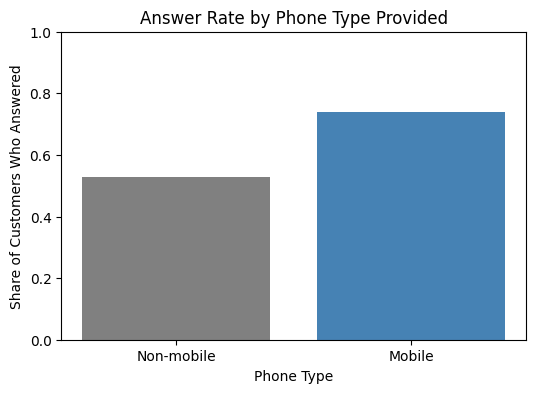

In [5]:
# Chart 1: Answer rate by phone type
mobile_rate = df.groupby('mobile')['answered'].mean()
labels = mobile_rate.index.map({0: 'Non-mobile', 1: 'Mobile'})

plt.figure(figsize=(6, 4))
plt.bar(labels, mobile_rate.values, color=['gray', 'steelblue'])
plt.title('Answer Rate by Phone Type Provided')
plt.xlabel('Phone Type')
plt.ylabel('Share of Customers Who Answered')
plt.ylim(0, 1)
plt.show()

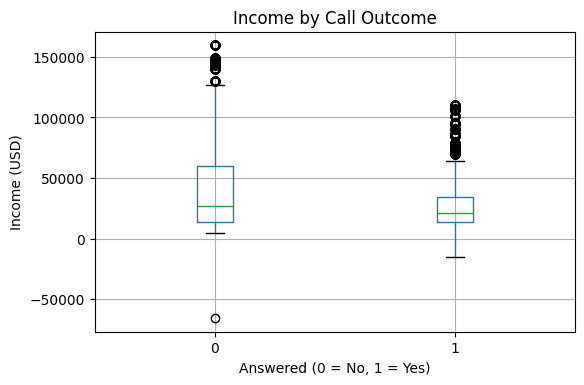

In [6]:
# Chart 2: Income distribution by call outcome
df.boxplot(column='income', by='answered', figsize=(6, 4))
plt.suptitle('')
plt.title('Income by Call Outcome')
plt.xlabel('Answered (0 = No, 1 = Yes)')
plt.ylabel('Income (USD)')
plt.show()

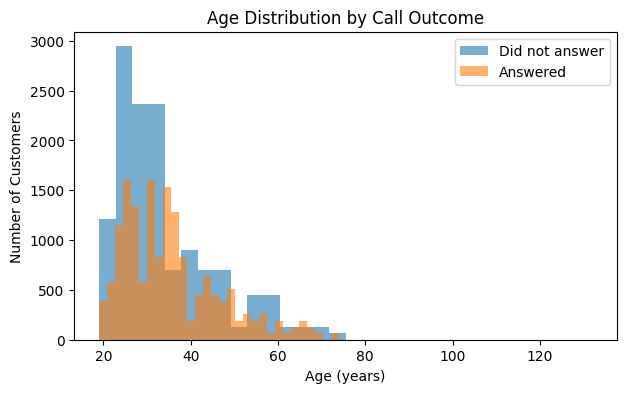

In [7]:
# Chart 3: Age distribution by call outcome
plt.figure(figsize=(7, 4))
plt.hist(df.loc[df['answered'] == 0, 'age'], bins=30, alpha=0.6, label='Did not answer')
plt.hist(df.loc[df['answered'] == 1, 'age'], bins=30, alpha=0.6, label='Answered')
plt.title('Age Distribution by Call Outcome')
plt.xlabel('Age (years)')
plt.ylabel('Number of Customers')
plt.legend()
plt.show()

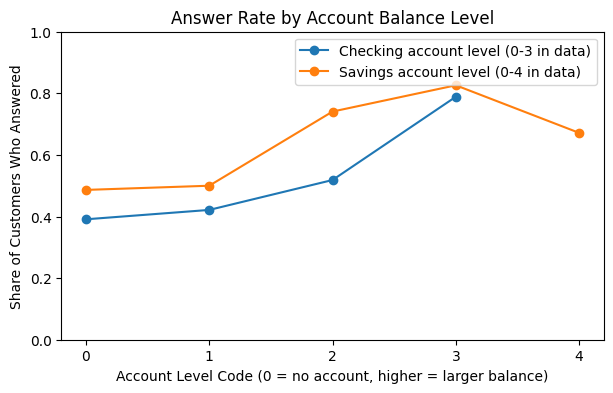

In [11]:
# Chart 4: Answer rate across checking and savings account levels
chk_rate = df.groupby('chk_acct')['answered'].mean()
sav_rate = df.groupby('sav_acct')['answered'].mean()

plt.figure(figsize=(7, 4))
plt.plot(chk_rate.index, chk_rate.values, marker='o', label='Checking account level (0-3 in data)')
plt.plot(sav_rate.index, sav_rate.values, marker='o', label='Savings account level (0-4 in data)')
plt.title('Answer Rate by Account Balance Level')
plt.xlabel('Account Level Code (0 = no account, higher = larger balance)')
plt.ylabel('Share of Customers Who Answered')
plt.xticks([0, 1, 2, 3, 4])
plt.ylim(0, 1)
plt.legend()
plt.show()

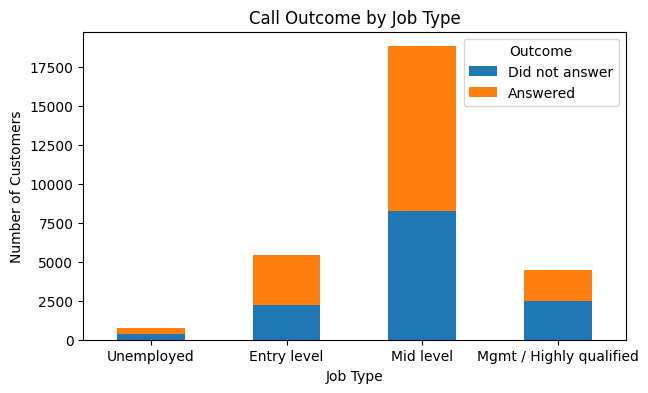

In [9]:
# Chart 5: Answered vs. not answered counts by job type
job_labels = {0: 'Unemployed', 1: 'Entry level', 2: 'Mid level', 3: 'Mgmt / Highly qualified'}
job_counts = pd.crosstab(df['job'], df['answered'])
job_counts = job_counts.rename(columns={0: 'Did not answer', 1: 'Answered'})
job_counts.index = job_counts.index.map(lambda x: job_labels.get(x, str(x)))

job_counts.plot(kind='bar', stacked=True, figsize=(7, 4))
plt.title('Call Outcome by Job Type')
plt.xlabel('Job Type')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.legend(title='Outcome')
plt.show()

# Step 3: Summarize Your Findings
- Question 3.1: Which variables are NOT useful or applicable to the business need?  (you should reference the target variable and list any variables that are not correlated with the target)

- Question 3.2: Which variables are MOST useful or applicable to the business need, based on the output of your charts?   

- Question 3.3: List at least three ways that the dataset could be improved.  What data quality issues or data types should be fixed?



### ✍️ Your Response: 🔧
3.1 Customer_id is only a label and has no relationship to whether a customer answers. Num_dependents and num_accts show almost no correlation with answered (about -0.01 and 0.01). Product should also be left out. It is recorded after the call, and a value of 0 means the customer did not answer. It restates the target and would not be available when we schedule calls, so it can't help us predict who will pick up.

3.2 Checking account level was the strongest signal in the charts. About 79% of customers in the highest checking level answered, compared with about 39% of customers with no checking account. Savings level showed a mostly upward pattern, though the answer rate dipped at the highest level. Customers who gave a mobile number answered at about 74%, compared with 53% for non-mobile numbers. Income also matters. Customers who answered had a lower median income than those who did not. Home ownership and a recent new car purchase showed smaller but real differences.

3.3 The dataset could be improved in five ways:

1. The female column is stored as text and contains one "M" value. It should be converted to a numeric 0/1 field. The coding also runs backwards, with 0 for female and 1 for male. Renaming the column to "male" would prevent confusion.
2. Impossible values should be fixed or removed. These include the negative incomes, the age of 132, and the num_accts value of 3,345.
3. New_car has two missing values and is stored as a float. The missing rows should be filled or dropped, and the column should be converted to an integer.
4. There are three duplicate rows that should be removed.
5. The data dictionary lists a checking level 4, but no customer has it. The balance ranges for levels 3 and 4 also overlap ("< 35000" and ">= 3500"), so the category definitions should be corrected.

## Submission Instructions

✅ **Before submitting:**
- Make sure all code cells are run and outputs are visible  
- All markdown questions are answered thoughtfully  
- Submit the assignment as an **HTML file** on Canvas

In [ ]:
!jupyter nbconvert --to html "assignment_04_data_understanding.ipynb"